# Anomaly Detection on the 40 MHz Dataset — Cascaded SMPO (19→2→1)

Baseline from: https://arxiv.org/pdf/2006.02516.pdf  
Idea and datasets extracted from https://arxiv.org/pdf/2108.03986

## Model
- **Architecture:** 19 → 2 → 1 (2-layer cascaded SMPO, open boundary)
- **Bond dimensions:** χ = [2, 2]
- **Physical dimensions:** (3, 3, 3)
- **Output positions:** centered

## Dataset
- 40 MHz LHC background, 4M events (70 / 5 / 25 % train/val/test split)
- Input: 19 particle features via `ParticleVectorEmbedding` (pt, η, φ per object + MET)
- Signals evaluated: A→4l, LQ→bτ, H→τν, H→ττ


**Imports**

In [ ]:
# let's import and set up os env variables
import os
import sys
os.environ["KMP_WARNINGS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "2" #Pick up the 2nd GPU on the node
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE") 

'FALSE'

In [ ]:
#import and configure jax this is needed first for precision?
import jax
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'float32')
jax.config.update("jax_platform_name", 'gpu')
print("JAX devices:", jax.devices())
print("JAX device kind:", jax.devices()[0].device_kind)

JAX devices: [CudaDevice(id=0)]
JAX device kind: NVIDIA A100-SXM4-40GB


In [3]:
# configure torch change precision if needed
import torch
torch.random.manual_seed(42)
torch.set_default_dtype(torch.float32)           
torch.set_float32_matmul_precision("highest")    # avoid TF32 approximations
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
print("PyTorch CUDA:", torch.cuda.is_available())

PyTorch CUDA: True


In [4]:
#import libraries
import jax.numpy as jnp
import numpy as np
import optax
import quimb.tensor as qtn
from sklearn.metrics import auc
from jax.nn.initializers import *
import matplotlib.pyplot as plt
import json

In [ ]:
#import local stuff
from tn4ml.initializers import *
from tn4ml.models.smpo import *
from tn4ml.models.model import *
from tn4ml.embeddings import *
from tn4ml.metrics import *
from tn4ml.util import *
from tn4ml.eval import *

# Set up paths
sys.path.insert(0, os.path.abspath('..'))
from cascaded_tn.training.cascaded_model import *

**Load 40 MHz dataset**

In [6]:
import utils.dataloader as d

inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/" #Change this based on wherever your datasets are located.
print(os.environ["HDF5_USE_FILE_LOCKING"]) #double check this should be false, otherwise there might be issues with reading the hdf5 files.
skip_MET_eta=False #Set this to True if you want to skip the MET eta feature in the dataset.
norm=True #Set this to True if you want to normalize the dataset features to zero mean and unit variance.
cartesian=False #Set this to True if you want to use cartesian coordinates (px, py, pz) instead of (pt, eta, phi).
normalize_tensors=False #Set to True if you want to normalize each particle tensor to unit norm.
normalize_MPS=True #Set to True if you want normalize the embedded MPS to unit frob norm.


FALSE


In [ ]:
# let's set up some utils for output path and storage of results 
outputFolder = "Compress_19_2_1_bd2_2_hub15"
outputPath = "../output/" + outputFolder + "/"
if not os.path.exists(outputPath):
    os.makedirs(outputPath)
else:
    print("Output folder already exists. Files might be overwritten.")

Output folder already exists. Files might be overwritten.


In [8]:
#let's make a dictionary to store the hyperparameters and results
to_store = {}

In [ ]:
batch_size = 2048
to_store['batch_size'] = batch_size
ordering = np.load("optimal_ordering.npy")
background_train, background_val, background_test = d.create_split_dataloaders(
    file_path=inputPath+"background_for_training.h5",
    batch_size=batch_size,
    split_ratios=(0.70, 0.05, 0.25),
    norm=norm,
    skip_MET_eta=skip_MET_eta,
    cartesian=cartesian,
    shuffle=True,
    shuffle_before_split=False,
    val_batch_size=10000,
    test_batch_size=10000,
    particle_ordering=ordering
)

[DATASET SPLITS]
  Total samples: 4,000,000
  Train: 2,800,000 (70.0%)
  Val:   200,000 (5.0%)
  Test:  1,000,000 (25.0%)

[DATALOADERS CREATED]
  Train batches: 1368
  Val batches:   20
  Test batches:  100


**Training setup** &nbsp;
- Stochastic Gradient Descent

In [ ]:
# define model parameters
initializer = jax.nn.initializers.variance_scaling(scale=2.0, mode='fan_avg', distribution='uniform')
key = jax.random.PRNGKey(42)

target_loss = 50
to_store['target_loss'] = target_loss

huber_delta = 15

embedding = ParticleVectorEmbedding(normalize=normalize_tensors)
add_identity = True
boundary='obc' # 'pbc' or 'obc' = periodic or open boundary conditions

In [15]:
def SmoothHuberNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """Symmetric smooth Huber loss."""
    x = TransformedNorm(model, data)
    error = x - target_loss

    delta = huber_delta  
    
    # Smooth Huber
    smooth_huber = delta**2 * (jnp.sqrt(1 + (error/delta)**2) - 1)
    
    # Very weak collapse prevention (only for x << target)
    collapse_penalty = jax.lax.select( x < 1., jax.lax.pow(jax.lax.log(x/target_loss), 2), 0.)
    
    return smooth_huber + collapse_penalty

In [ ]:
ChosenLossFunction = SmoothHuberNorm

to_store['loss_function'] = ChosenLossFunction.__name__

if "HuberNorm" in ChosenLossFunction.__name__:
    to_store['huber_delta'] = huber_delta

alpha = 0.04
def loss_combined(*args, **kwargs):
    error = ChosenLossFunction
    reg = lambda P: 0.0 # No regularization used in the training
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))

In [ ]:
#define the model parameters here to store in the hyperparameters file 
layer_dims=[19,2,1]
bond_dims=[2,2]
phys_dims=[3,3,3]
enable_relu=False
lr=5e-3
optimizer=optax.adam
cyclic=False

to_store['layer_dims'] = layer_dims
to_store['bond_dims'] = bond_dims
to_store['phys_dims'] = phys_dims
to_store['enable_relu'] = enable_relu
to_store['cyclic'] = cyclic
to_store['learning_rate'] = lr

encoder = create_trainable_encoder(
    layer_dims=layer_dims,
    bond_dims=bond_dims,
    phys_dims=phys_dims,
    enable_relu=enable_relu,
    output_positions='center',
    cyclic=cyclic,
    key=key,
    debug=False,
    initializer=initializer,
    add_identity=add_identity,
    boundary=boundary,
    optimizer=optimizer,
    learning_rate=lr,
    loss_function=loss_combined,
)

In [ ]:
result_folder = outputPath + "/plots/"
os.makedirs(result_folder, exist_ok=True)
print(f"   Parameters: {encoder.nparams():,}")
print(f"   Architecture: {[op.config.input_dim for op in encoder.cascade.operators]} → {encoder.cascade.operators[-1].config.output_dim}")
encoder.summary()

   Parameters: 264
   Architecture: [19, 2] → 1

CASCADED MODEL SUMMARY

CASCADE SUMMARY: OpenAutoencoder_19to1
Architecture: 19 → 2 → 1

Layers: 2
  0: Unified↓(19→2, χ=2)
  1: Unified↓(2→1, χ=2) (bottleneck)


Training Configuration:
  Strategy: global
  Optimizer: GradientTransformationExtraArgs(init=<function chain.<locals>.init_fn at 0x7f38c4c6aa20>, update=<function chain.<locals>.update_fn at 0x7f38c4c6ad40>)
  Learning rate: 0.005
  Loss function: <function loss_combined at 0x7f3934b28f40>
  Training type: 0

Total parameters: 264

Parameters by layer:
  Layer 0 (Unified↓(19→2, χ=2)): 240 parameters
  Layer 1 (Unified↓(2→1, χ=2)): 24 parameters



In [23]:
def loss_fn(data, targets, *params):

    temp_model = encoder.copy()

    # Update with new parameters
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)

    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    return encoder.loss(temp_model, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*encoder.L), backend=encoder.device)

In [24]:
@jax.jit
def compute_error_batch(sample_batch, *params):
    """JIT-compiled error computation for the batch"""
    def single_error(data_point, *p):
        # Create temp model and update params
        temp_model = encoder.copy()
        for tensor, param in zip(temp_model.tensors, p):
            tensor.modify(data=param)
        
        # Compute error for single point
        tn_i = embed(data_point, embedding)
        return ChosenLossFunction(temp_model, tn_i)
    
    # Vectorize over batch
    errors = jax.vmap(single_error, in_axes=[0] + [None]*len(params))(sample_batch, *params)
    return jnp.mean(errors)

In [25]:
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+encoder.L)), in_axes=[0, None] + [None]*encoder.L), backend=encoder.device)

params = encoder.arrays
encoder.step, encoder.opt_state = encoder.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)

In [26]:
@jax.jit
def train_step_jitted(params, opt_state, batch):
    # Compute loss and gradients in one go
    loss_val, grads = jax.value_and_grad(
        lambda *p: jnp.mean(jax.vmap(loss_fn, in_axes=[0, None] + [None]*len(p))(batch, None, *p)),
        argnums=range(len(params))
    )(*params)
    
    # Update parameters
    grads_dict = {i: g for i, g in enumerate(grads)}
    params_dict = {i: p for i, p in enumerate(params)}
    
    updates, opt_state = encoder.optimizer.update(grads_dict, opt_state)
    params_dict = optax.apply_updates(params_dict, updates)
    
    return tuple(params_dict.values()), opt_state, loss_val

In [27]:
from utils.training_tools import *
from tqdm import tqdm
import time

epochs = 200
to_store['epochs'] = (epochs)
history = { 'loss': [], 
            'val_loss' : [],
            'epoch_time': [], 
            'best_epoch': -1,
            'unfinished': True}

# Initialize early stopping
early_stopper = SimpleEarlyStopping(patience=50, min_delta=0.0001)

print(f"[TRAINING] Starting training with early stopping (patience={early_stopper.patience}, min_delta={early_stopper.min_delta})")
print(f"[DATA] Train batches: {len(background_train)}, Val batches: {len(background_val)}")

# Create checkpoint directory
checkpoint_dir = os.path.join(outputPath, "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"[CHECKPOINTS] Saving to {checkpoint_dir}")

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0

    for i, batch in enumerate(tqdm(background_train, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float32)
        params = encoder.arrays
        params, encoder.opt_state, loss = train_step_jitted(params, encoder.opt_state, batch)
        encoder.update_tensors(params)
        epoch_loss += loss

    end_time = time.time()
    avg_loss = epoch_loss / len(background_train)

    # Compute individual loss terms for monitoring using the existing loss functions
    # Get current model parameters

    val_loss = evaluate_validation_error(background_val, encoder, compute_error_batch)

    history['loss'].append(avg_loss)
    history['val_loss'].append(val_loss)
    history['epoch_time'].append(end_time - start_time)
    
    # Print epoch summary
    print(f"[Epoch {epoch+1}] Train Loss: {avg_loss:.3f} | Val Loss: {val_loss:.3f} | "
          f"Time: {end_time - start_time:.2f}s")
    
    # Early stopping check
    if early_stopper.check(val_loss, encoder, epoch):
        print(f"[EARLY STOPPING] Training stopped at epoch {epoch + 1}")
        history['best_epoch'] = early_stopper.best_epoch
        
        # Restore best model
        early_stopper.restore_best_model(encoder)
        
        # Mark as finished (even though stopped early, it's a successful completion)
        history['unfinished'] = False
        break
    
    # Save checkpoint every epoch
    checkpoint_path = os.path.join(checkpoint_dir, f"epoch_{epoch+1:03d}.pkl")
    encoder.save(checkpoint_path)
    print(f"[CHECKPOINT] Saved epoch {epoch+1} to {checkpoint_path}")

    # If training completes all epochs
    if epoch == epochs - 1:
        history['unfinished'] = False
        history['best_epoch'] = early_stopper.best_epoch

# Final summary
print("\n" + "="*80)
print("[TRAINING COMPLETE]")
print(f"  Total epochs run: {len(history['loss'])}")
print(f"  Best epoch: {history['best_epoch'] + 1}")
print(f"  Best validation error: {early_stopper.best_loss:.3f}")
print(f"  Final validation error: {history['val_loss'][-1]:.3f}")
print("="*80)

# Save final best model
final_model_path = os.path.join(outputPath, "final_best_model.pkl")
encoder.save(final_model_path)
print(f"[SAVED] Final best model saved to {final_model_path}")

[TRAINING] Starting training with early stopping (patience=50, min_delta=0.0001)
[DATA] Train batches: 1368, Val batches: 20
[CHECKPOINTS] Saving to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/checkpoints


Epoch 1/200:   0%|          | 0/1368 [00:00<?, ?it/s]

Epoch 1/200: 100%|██████████| 1368/1368 [01:05<00:00, 20.87it/s]


[Epoch 1] Train Loss: 56.126 | Val Loss: 23.598 | Time: 65.60s
[CHECKPOINT] Saved epoch 1 to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/checkpoints/epoch_001.pkl


Epoch 2/200: 100%|██████████| 1368/1368 [01:00<00:00, 22.60it/s]


...

[Epoch 198] Train Loss: 0.112 | Val Loss: 0.029 | Time: 60.25s
[CHECKPOINT] Saved epoch 198 to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/checkpoints/epoch_198.pkl


Epoch 199/200: 100%|██████████| 1368/1368 [01:00<00:00, 22.68it/s]


[Epoch 199] Train Loss: 0.113 | Val Loss: 0.026 | Time: 60.33s
[CHECKPOINT] Saved epoch 199 to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/checkpoints/epoch_199.pkl


Epoch 200/200: 100%|██████████| 1368/1368 [01:01<00:00, 22.20it/s]


[Epoch 200] Train Loss: 0.110 | Val Loss: 0.134 | Time: 61.62s
[CHECKPOINT] Saved epoch 200 to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/checkpoints/epoch_200.pkl

[TRAINING COMPLETE]
  Total epochs run: 200
  Best epoch: 169
  Best validation error: 0.016
  Final validation error: 0.134
[SAVED] Final best model saved to ../output/Reorder_Compress_19_2_1_bd2_2_hub15_center_out_fixed/final_best_model.pkl


In [29]:
os.makedirs(outputPath, exist_ok=True)
out_file = os.path.join(outputPath, "hyperparameters.json")
with open(out_file, "w") as f:
    json.dump(to_store, f, indent=2)

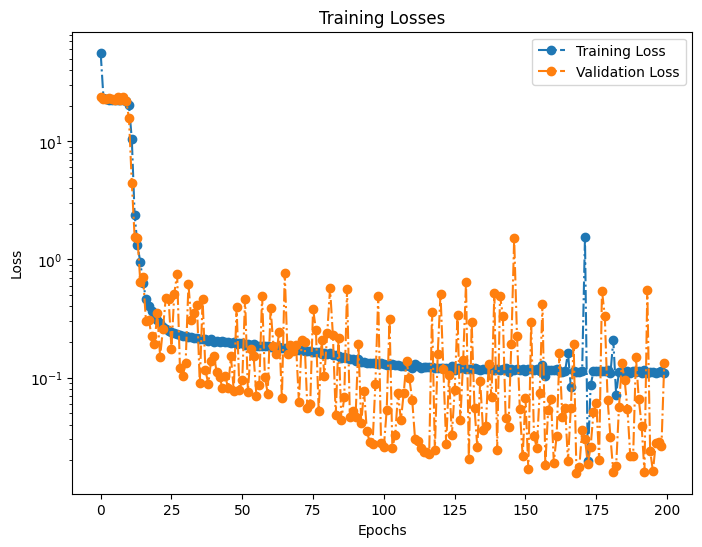

In [ ]:
plt.figure(figsize=(8, 6))
plt.yscale('log')
plt.plot(range(len(history['loss'])), history['loss'], linestyle="-.", marker='o', label='Training Loss')
plt.plot(range(len(history['val_loss'])), history['val_loss'], linestyle="-.", marker='o', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.savefig(result_folder+'training_loss.png', dpi=300)

**Evaluate**

In [31]:
a4l = d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian, particle_ordering=ordering)
lq = d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian, particle_ordering=ordering)
htnu = d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian, particle_ordering=ordering)
htt = d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, skip_MET_eta=skip_MET_eta, shuffle=True, norm=norm, cartesian=cartesian, particle_ordering=ordering)

In [32]:
def InputsToNorm(model: SpacedMatrixProductOperator, data: qtn.MatrixProductState) -> Number:
    """The norm itself
    
    Parameters
    ----------
    model : :class:`tn4ml.models.smpo.SpacedMatrixProductOperator`
        Spaced Matrix Product Operator
    data: :class:`quimb.tensor.MatrixProductState`
        Input mps.
    Returns
    -------
    float
    """
    x = TransformedNorm(model, data)
    return x

@jax.jit
def ComputeNorm(data, targets, *params):
    """Compute only the transformed norm"""
    # Create temp model with updated parameters
    temp_model = encoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    # Embed the scalar data to MPS
    tn_i = embed(data, embedding)
    
    # Return only error term (no regularization)
    return InputsToNorm(temp_model, tn_i)

# Vectorize it for batch processing
norm_term = jax.jit(jax.vmap(ComputeNorm, in_axes=[0, None] + [None]*encoder.L), backend='gpu')

In [34]:
def evaluate_model(model, dataloader, loss_func, verbose=True):
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float32)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples

In [35]:
# Run the evaluation on bkg and signals
bkg_train_norm = evaluate_model(encoder, background_train, norm_term, verbose=True)
bkg_val_norm = evaluate_model(encoder, background_val, norm_term, verbose=True)
bkg_test_norm = evaluate_model(encoder, background_test, norm_term, verbose=True)
a4l_norm = evaluate_model(encoder, a4l, norm_term, verbose=True)
lq_norm = evaluate_model(encoder, lq, norm_term, verbose=True)
htnu_norm = evaluate_model(encoder, htnu, norm_term, verbose=True)
htt_norm  = evaluate_model(encoder, htt, norm_term, verbose=True)

Evaluating: 100%|██████████| 70/70 [00:07<00:00,  9.31it/s]


In [ ]:
## The anomaly score is defined as the distance from the testing dataset norm median
new_target = np.median(bkg_train_norm)
bkg_score = np.abs(bkg_test_norm-new_target)
lq_score = np.abs(lq_norm-new_target)
a4l_score = np.abs(a4l_norm-new_target)
htt_score = np.abs(htt_norm-new_target)
htnu_score = np.abs(htnu_norm-new_target)

**Plot anomaly scores and ROC curve**

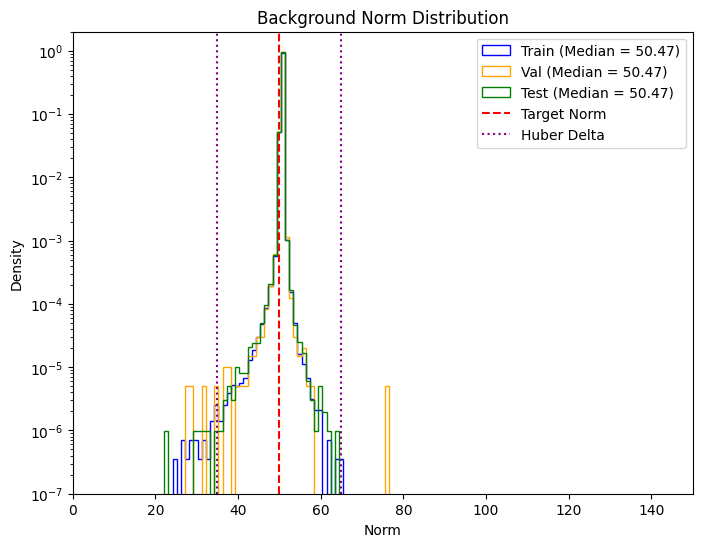

In [38]:
# Train, test, validation norm compatibility plots
plt.figure(figsize=(8, 6))
plt.yscale('log')
xmin = 0
xmax = 150
bins = np.linspace(xmin, xmax, xmax-xmin)
plt.hist(bkg_train_norm, bins=bins, density=True, label=f'Train (Median = {np.median(bkg_train_norm):.2f})', color='blue', histtype='step')
plt.hist(bkg_val_norm, bins=bins, density=True, label=f'Val (Median = {np.median(bkg_val_norm):.2f})', color='orange', histtype='step')
plt.hist(bkg_test_norm, bins=bins, density=True, label=f'Test (Median = {np.median(bkg_test_norm):.2f})', color='green', histtype='step')
plt.axvline(target_loss, color='red', linestyle='--', label='Target Norm')
if "HuberNorm" in ChosenLossFunction.__name__:
   plt.axvline(target_loss - huber_delta, color='purple', linestyle=':', label='Huber Delta')
   plt.axvline(target_loss + huber_delta, color='purple', linestyle=':')
plt.title('Background Norm Distribution')
plt.xlabel('Norm')
plt.ylabel('Density')
plt.xlim([xmin, xmax])
plt.ylim([1e-7, 2])
plt.legend()
plt.savefig(result_folder+'bkg_norm_compatibility.png', dpi=300)

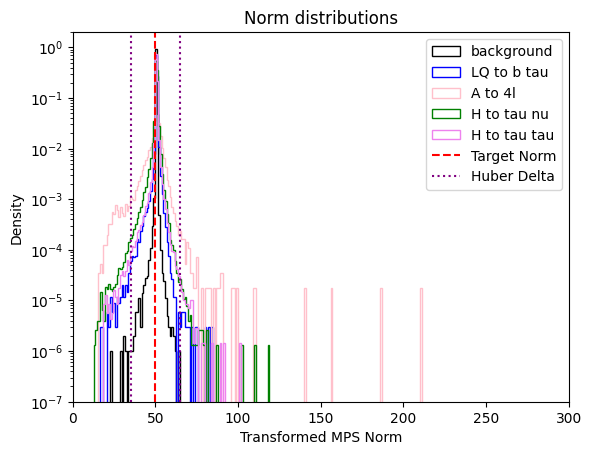

In [ ]:
plt.figure()
plt.yscale('log')
xmin = 0
xmax = 300
bins = np.linspace(xmin-0.5, xmax-0.5, xmax-xmin)
plt.hist(bkg_test_norm, bins=bins, histtype='step', color='black', label='background', density=True)
plt.hist(lq_norm, bins=bins, histtype='step', color='blue', label='LQ to b tau', density=True)
plt.hist(a4l_norm, bins=bins, histtype='step', color='pink', label='A to 4l', density=True)
plt.hist(htnu_norm, bins=bins, histtype='step', color='green', label='H to tau nu', density=True)
plt.hist(htt_norm, bins=bins, histtype='step', color='violet', label='H to tau tau', density=True)
plt.axvline(target_loss, color='red', linestyle='--', label='Target Norm')
if "HuberNorm" in ChosenLossFunction.__name__:
   plt.axvline(target_loss - huber_delta, color='purple', linestyle=':', label='Huber Delta')
   plt.axvline(target_loss + huber_delta, color='purple', linestyle=':')
plt.title('Norm distributions')
plt.xlim([xmin, xmax])
plt.ylim([1e-7, 2])
plt.xlabel('Transformed MPS Norm')
plt.ylabel('Density')
plt.legend()
plt.savefig(result_folder+'transformed_norms.png', dpi=300)

In [40]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 13.268951


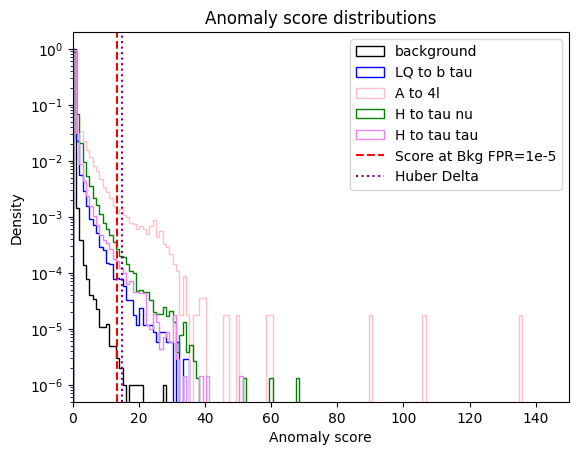

In [ ]:
plt.figure()
plt.yscale('log')
xmin = 0
xmax = 150
bins = np.linspace(xmin, xmax, xmax-xmin)
plt.hist(bkg_score, bins=bins, histtype='step', color='black', label='background', density=True)
plt.hist(lq_score, bins=bins, histtype='step', color='blue', label='LQ to b tau', density=True)
plt.hist(a4l_score, bins=bins, histtype='step', color='pink', label='A to 4l', density=True)
plt.hist(htnu_score, bins=bins, histtype='step', color='green', label='H to tau nu', density=True)
plt.hist(htt_score, bins=bins, histtype='step', color='violet', label='H to tau tau', density=True)
plt.axvline(score_threshold, color='red', linestyle='--', label='Score at Bkg FPR=1e-5')
if "HuberNorm" in ChosenLossFunction.__name__:
   plt.axvline(huber_delta, color='purple', linestyle=':', label='Huber Delta')
plt.title('Anomaly score distributions')
plt.xlim([xmin, xmax])
plt.xlabel('Anomaly score')
plt.ylabel('Density')
plt.legend()
plt.savefig(result_folder+'anomaly_scores.png', dpi=300)

In [43]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

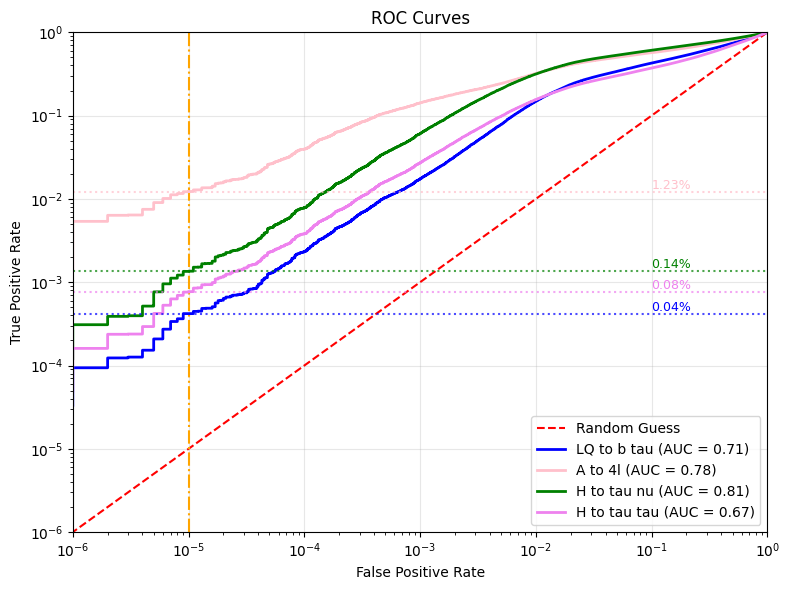

In [44]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="right")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(result_folder+'roc_curves.png', dpi=300)